In [1]:
pip install transformers torch torchvision Pillow matplotlib scikit-learn

--- Инициализация на cuda ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Извлекаем признаки изображений (около минуты)...

[РЕЗУЛЬТАТ] Общая Zero-shot accuracy: 79.87%

Отрисовка матрицы ошибок...


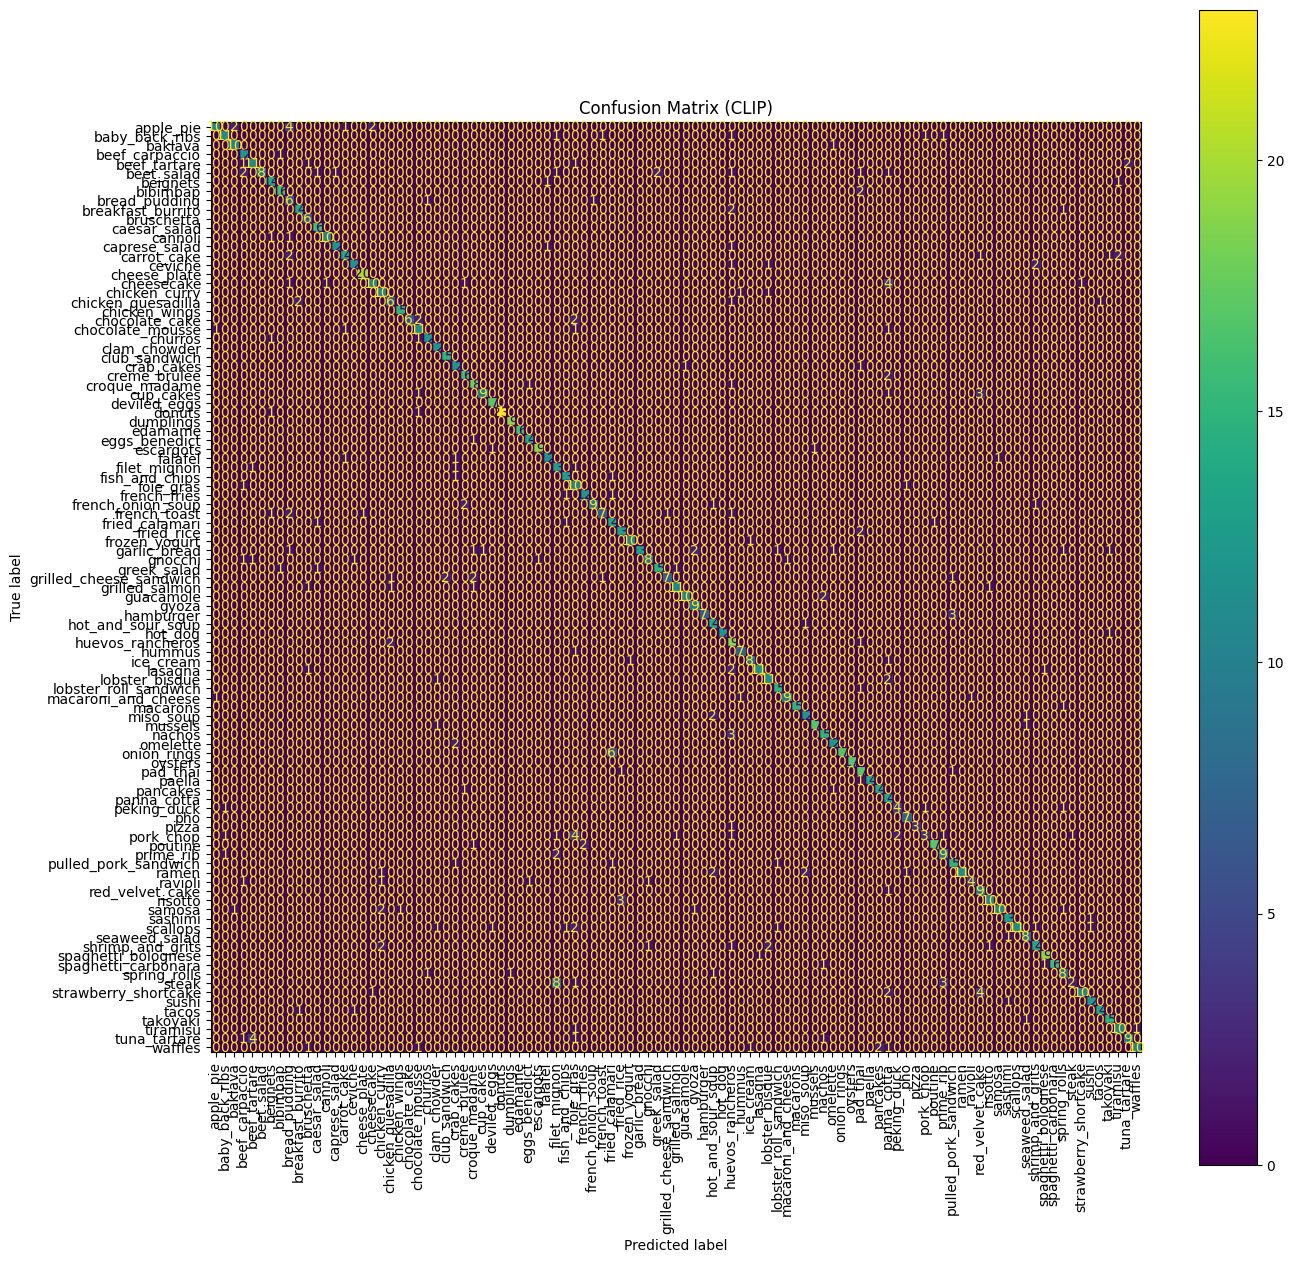


--- Эксперименты с 4 шаблонами промптов ---
Худший шаблон: '{}' -> 76.2%
Лучший шаблон: 'a delicious dish of {}' -> 80.0%
Ансамбль (все 4 шаблона): -> 80.4%

--- Анализ Топ-6 ошибок модели ---


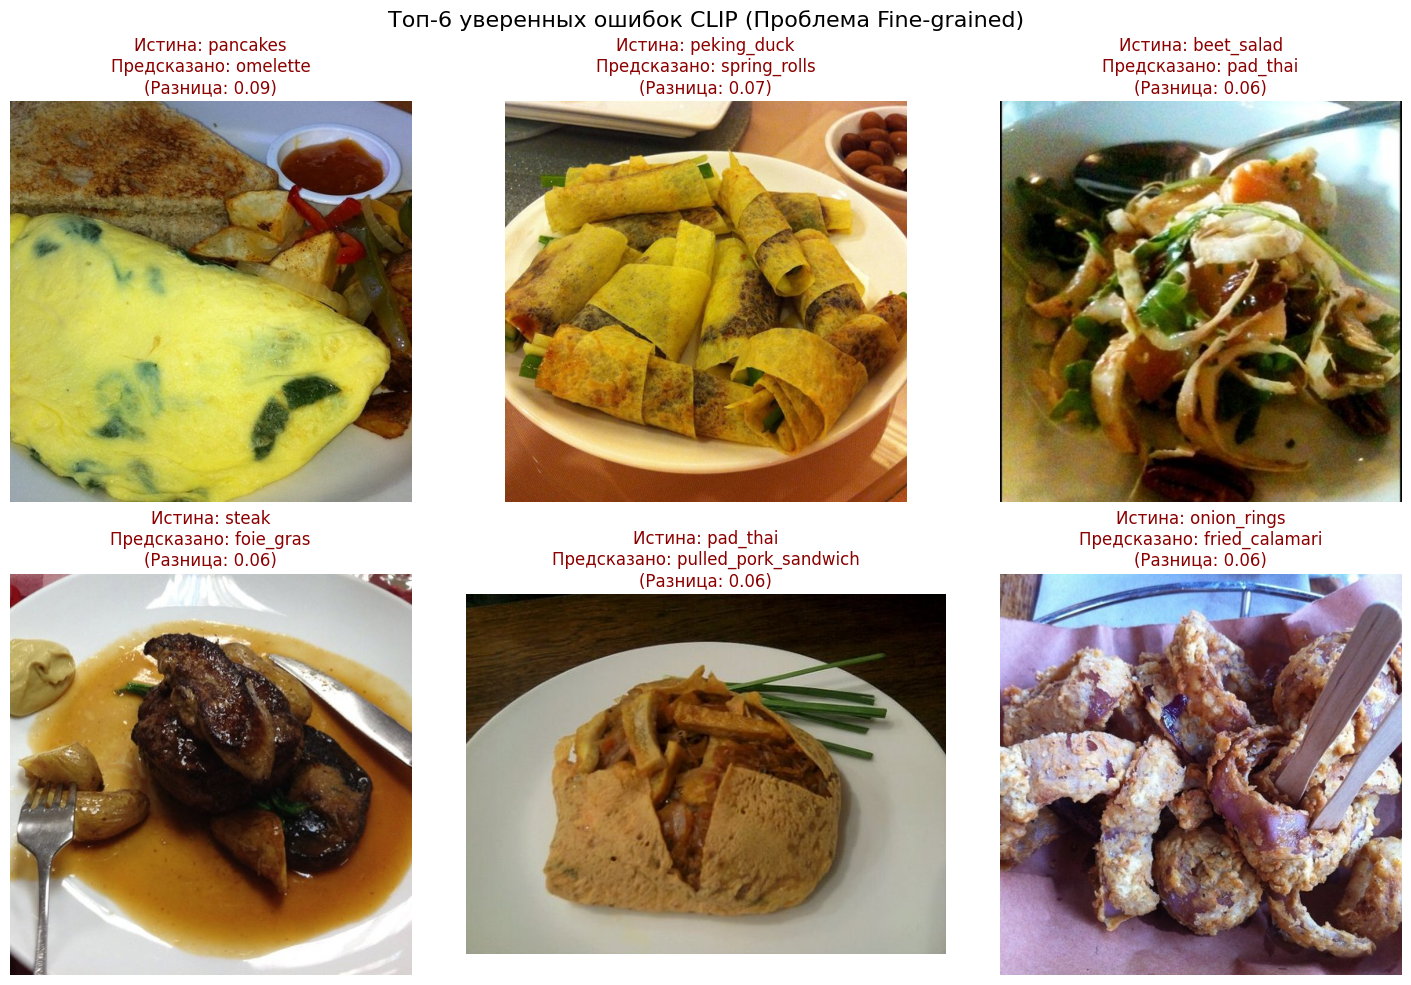

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import CLIPModel, CLIPProcessor
from torch.utils.data import DataLoader, Subset
from torchvision import datasets
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import gc

# ==========================================
# 0. Подготовка среды и инициализация модели
# ==========================================

# Принудительная сборка мусора и очистка кэша видеокарты.
# Полезно при перезапуске ячеек в Jupyter Notebook, чтобы избежать ошибки Out Of Memory (OOM).
gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()

# Выбор устройства для вычислений: если есть GPU (CUDA), используем его для ускорения, иначе CPU.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"--- Инициализация на {device} ---")

# Загружаем предобученную модель CLIP (архитектура ViT-base с размером патча 32x32).
model_id = "openai/clip-vit-base-patch32"
# Переносим веса модели на выбранное устройство (CPU/GPU)
model = CLIPModel.from_pretrained(model_id).to(device)
# Загружаем процессор, который умеет правильно токенизировать текст и нормализовать картинки под эту конкретную модель
processor = CLIPProcessor.from_pretrained(model_id)

def custom_collate(batch):
    """
    Кастомная функция для сборки батча из DataLoader.
    Стандартный collate_fn пытается превратить PIL-картинки в тензоры PyTorch.
    Нам это не нужно, так как CLIPProcessor ожидает на вход именно списки сырых PIL-изображений.
    """
    images = [item[0] for item in batch] # Извлекаем PIL-изображения
    labels = [item[1] for item in batch] # Извлекаем метки классов
    return images, torch.tensor(labels)

# ==========================================
# 1. Загрузка данных
# ==========================================

# Загружаем датасет Food101 (101 класс различной еды). 
# transform=None, так как обработкой изображений будет заниматься CLIPProcessor.
full_dataset = datasets.Food101(root='./data', split='test', download=True, transform=None)
class_names = full_dataset.classes # Список всех названий блюд

# Чтобы ускорить процесс и не переполнить память, берем случайную подвыборку (1500 картинок).
np.random.seed(42) # Фиксируем сид для воспроизводимости эксперимента
subset_indices = np.random.choice(len(full_dataset), 1500, replace=False).tolist()
test_dataset = Subset(full_dataset, subset_indices)

# Создаем загрузчик данных. Разделяем 1500 картинок на пачки (батчи) по 32 штуки.
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=custom_collate)

# ==========================================
# 2. Базовые эмбеддинги текста
# ==========================================

# Формируем базовые текстовые описания для каждого из 101 класса.
# "A photo of a..." помогает CLIP лучше понять контекст, так как он обучался на таких парах в интернете.
text_descriptions = [f"a photo of a {name}" for name in class_names]

# Токенизируем текст и переносим тензоры на GPU/CPU
text_inputs = processor(text=text_descriptions, return_tensors="pt", padding=True).to(device)

with torch.no_grad(): # Отключаем расчет градиентов (мы только делаем инференс, а не обучаем модель)
    # Прогоняем текст через текстовый энкодер CLIP
    text_features = model.get_text_features(**text_inputs)
    # В зависимости от версии transformers, метод может вернуть объект или сразу тензор. Обрабатываем это:
    if not isinstance(text_features, torch.Tensor): 
        text_features = text_features.pooler_output
        
    # L2-нормализация текстовых векторов (эмбеддингов).
    # Это критически важно: после нормализации длины всех векторов равны 1.
    # Благодаря этому скалярное произведение (dot product) векторов будет равно их косинусному сходству (cosine similarity).
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

# ==========================================
# 3. Извлечение визуальных признаков и Zero-shot классификация
# ==========================================
print("Извлекаем признаки изображений (около минуты)...")
all_preds, all_labels, all_image_features = [], [], []

model.eval() # Переводим модель в режим оценки (отключает Dropout и др. слои, нужные только при обучении)
with torch.no_grad():
    for images, labels in test_loader:
        # Подготавливаем батч изображений (ресайз, нормализация под формат CLIP)
        image_inputs = processor(images=images, return_tensors="pt", padding=True).to(device)
        
        # Получаем визуальные эмбеддинги
        image_features = model.get_image_features(**image_inputs)
        if not isinstance(image_features, torch.Tensor): 
            image_features = image_features.pooler_output
            
        # L2-нормализация визуальных векторов (аналогично тексту)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        # Вычисляем сходство (similarity) между текущим батчем картинок и ВСЕМИ 101 текстовыми описаниями.
        # Матричное умножение (@): размерность [32, 512] @ [512, 101] -> [32, 101].
        # Получаем матрицу логитов, где для каждой картинки есть 101 оценка сходства.
        similarity = image_features @ text_features.T
        
        # Берем индекс текстового описания с максимальной оценкой (это и есть наше предсказание)
        preds = similarity.argmax(dim=1)

        # Собираем данные со всех батчей для дальнейшего анализа.
        # Переносим на CPU и конвертируем в numpy для удобства работы с sklearn/matplotlib.
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_image_features.append(image_features.cpu())

# Превращаем списки в сплошные массивы
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_image_features = torch.cat(all_image_features) # Склеиваем эмбеддинги всех картинок в один тензор [1500, 512]

# Считаем общую долю правильных ответов (Accuracy)
accuracy = np.mean(all_preds == all_labels)
print(f"\n[РЕЗУЛЬТАТ] Общая Zero-shot accuracy: {accuracy * 100:.2f}%\n")

# ==========================================
# 4. Матрица ошибок
# ==========================================
print("Отрисовка матрицы ошибок...")
# Генерируем матрицу ошибок размером 101x101. labels=range... гарантирует, что размерность не сломается,
# даже если какие-то классы случайно не попали в нашу выборку 1500 картинок.
cm = confusion_matrix(all_labels, all_preds, labels=range(len(class_names)))
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)

# Отрисовываем матрицу. Делаем большой размер графика (15х15), иначе 101 класс просто сольется в пиксельное месиво.
fig, ax = plt.subplots(figsize=(15, 15))
disp.plot(ax=ax, xticks_rotation=90) # Поворачиваем подписи на оси X вертикально
plt.title("Confusion Matrix (CLIP)")
plt.show()

# ==========================================
# 5. Эксперименты с промптами (Prompt Engineering)
# ==========================================
print("\n--- Эксперименты с 4 шаблонами промптов ---")
# Разные формулировки могут давать разное качество предсказания.
templates = [
    "{}", # Голое название класса (обычно работает хуже всего)
    "a photo of a {}", # Базовый шаблон
    "a delicious dish of {}", # Специфичный для датасета еды
    "a close-up photograph of {}" # Детализированный
]

prompt_accuracies = {}
text_features_ensemble = [] # Здесь будем хранить фичи всех шаблонов для ансамбля

for t_idx, template in enumerate(templates):
    # Генерируем промпты для текущего шаблона
    desc = [template.format(name) for name in class_names]
    t_inputs = processor(text=desc, return_tensors="pt", padding=True).to(device)
    
    with torch.no_grad():
        t_feat = model.get_text_features(**t_inputs)
        if not isinstance(t_feat, torch.Tensor): t_feat = t_feat.pooler_output
        t_feat = t_feat / t_feat.norm(dim=-1, keepdim=True) # Нормализация

        # Считаем сходство между заранее сохраненными фичами картинок и текущими фичами текста
        sim = all_image_features @ t_feat.cpu().T
        acc = np.mean(sim.argmax(dim=1).numpy() == all_labels)
        prompt_accuracies[template] = acc

        text_features_ensemble.append(t_feat) # Сохраняем для ансамбля

# Ансамблирование промптов (Prompt Ensembling)
# Мы усредняем векторы всех 4 шаблонов для каждого класса. 
# Это сглаживает шум от неудачных формулировок и создает более "крепкий" текстовый эмбеддинг.
ensemble_features = torch.stack(text_features_ensemble).mean(dim=0)
# После усреднения векторы нужно снова нормализовать!
ensemble_features = ensemble_features / ensemble_features.norm(dim=-1, keepdim=True)

# Считаем точность ансамбля
ensemble_sim = all_image_features @ ensemble_features.cpu().T
ensemble_acc = np.mean(ensemble_sim.argmax(dim=1).numpy() == all_labels)

best_prompt = max(prompt_accuracies, key=prompt_accuracies.get)
worst_prompt = min(prompt_accuracies, key=prompt_accuracies.get)

print(f"Худший шаблон: '{worst_prompt}' -> {prompt_accuracies[worst_prompt]*100:.1f}%")
print(f"Лучший шаблон: '{best_prompt}' -> {prompt_accuracies[best_prompt]*100:.1f}%")
print(f"Ансамбль (все 4 шаблона): -> {ensemble_acc*100:.1f}%\n")

# ==========================================
# 6. Анализ ошибок (Топ-6 самых уверенных ошибок)
# ==========================================
print("--- Анализ Топ-6 ошибок модели ---")
# Находим индексы всех картинок, где предсказание не совпало с реальностью
errors_mask = all_preds != all_labels
error_indices = np.where(errors_mask)[0]

# Полная матрица сходства для всех картинок и базовых текстовых описаний
sim_matrix = (all_image_features @ text_features.cpu().T).numpy()

error_confidences = []
for idx in error_indices:
    pred_c = all_preds[idx] # Класс, который модель выбрала ошибочно
    true_c = all_labels[idx] # Реальный класс
    
    # "Уверенность в ошибке". 
    # Считаем разницу между скором ошибочного класса и скором правильного класса.
    # Чем больше разница, тем сильнее модель была уверена в своей неправоте.
    conf = sim_matrix[idx, pred_c] - sim_matrix[idx, true_c]
    error_confidences.append((idx, conf))

# Сортируем ошибки по убыванию уверенности и берем топ-6
top_errors = sorted(error_confidences, key=lambda x: x[1], reverse=True)[:6]

# Отрисовываем сетку из 6 самых проблемных изображений
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Топ-6 уверенных ошибок CLIP (Проблема Fine-grained)", fontsize=16)

for i, (idx, conf) in enumerate(top_errors):
    ax = axes[i // 3, i % 3] # Математика для распределения картинок по сетке 2х3
    img, true_label = test_dataset[idx]
    pred_label = all_preds[idx]

    ax.imshow(img)
    # Выводим реальный и предсказанный классы, а также разницу в уверенности
    ax.set_title(f"Истина: {class_names[true_label]}\nПредсказано: {class_names[pred_label]}\n(Разница: {conf:.2f})", color="darkred")
    ax.axis('off') # Убираем оси координат для красоты

plt.tight_layout() # Автоматически подгоняет отступы, чтобы текст не наезжал на картинки
plt.show()

In [3]:
!pip install faiss-cpu

--- Задание 2: Image Retrieval (Поиск по тексту) ---


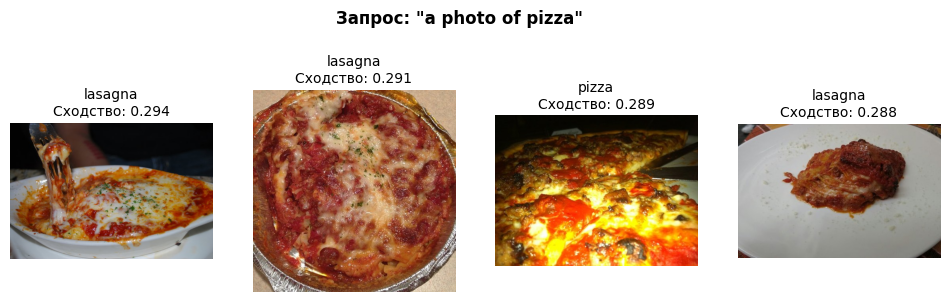

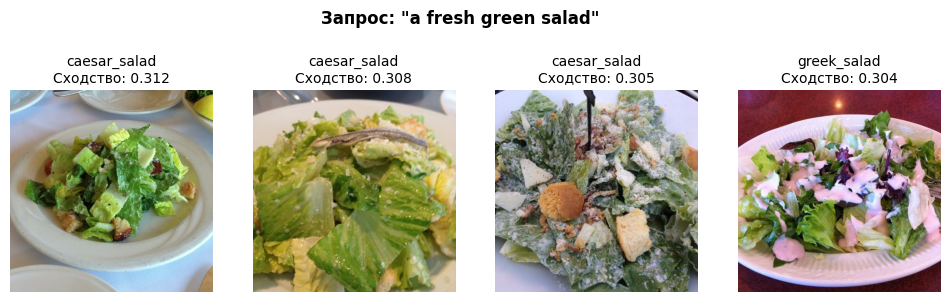

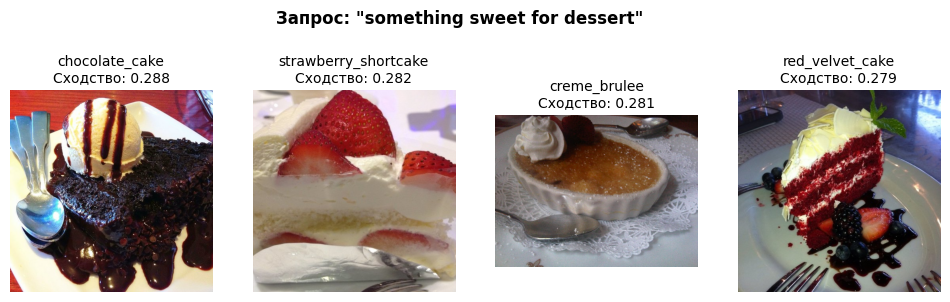

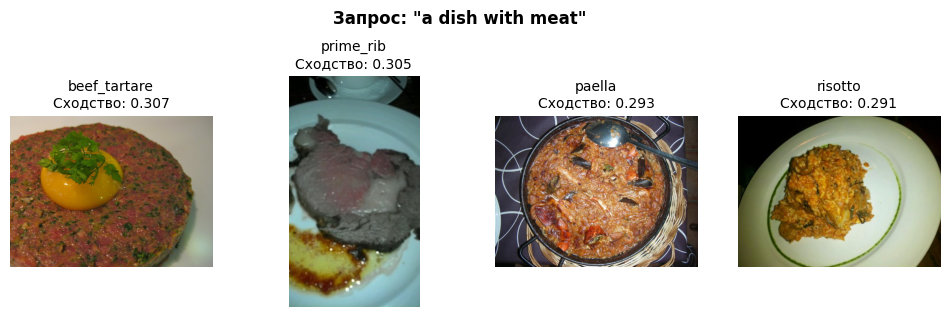

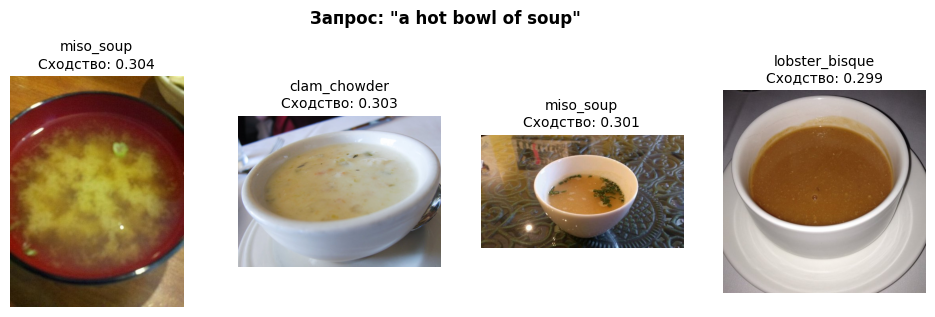

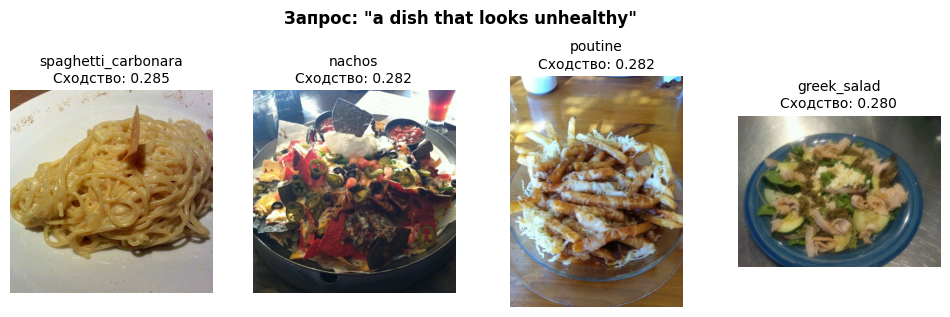

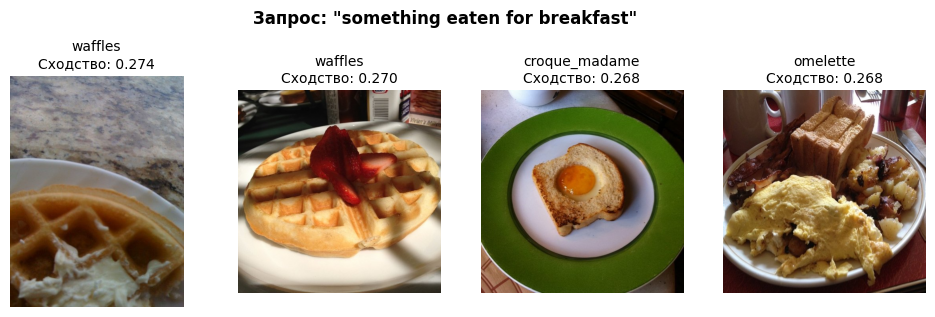

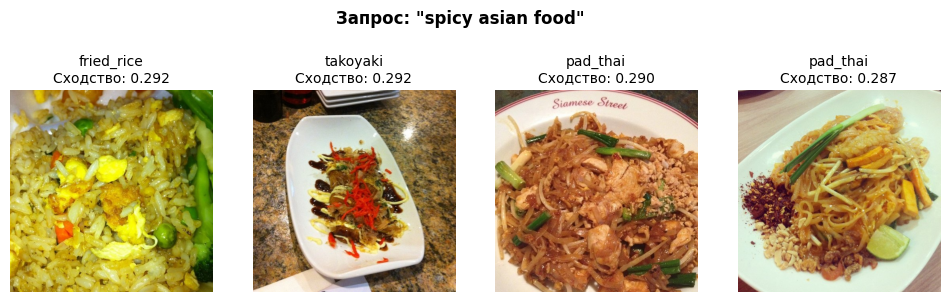


--- Подсчет качества поиска (Recall@10) ---
[РЕЗУЛЬТАТ] Mean Recall@10: 100.0%

--- Визуализация эмбеддингов (t-SNE) ---


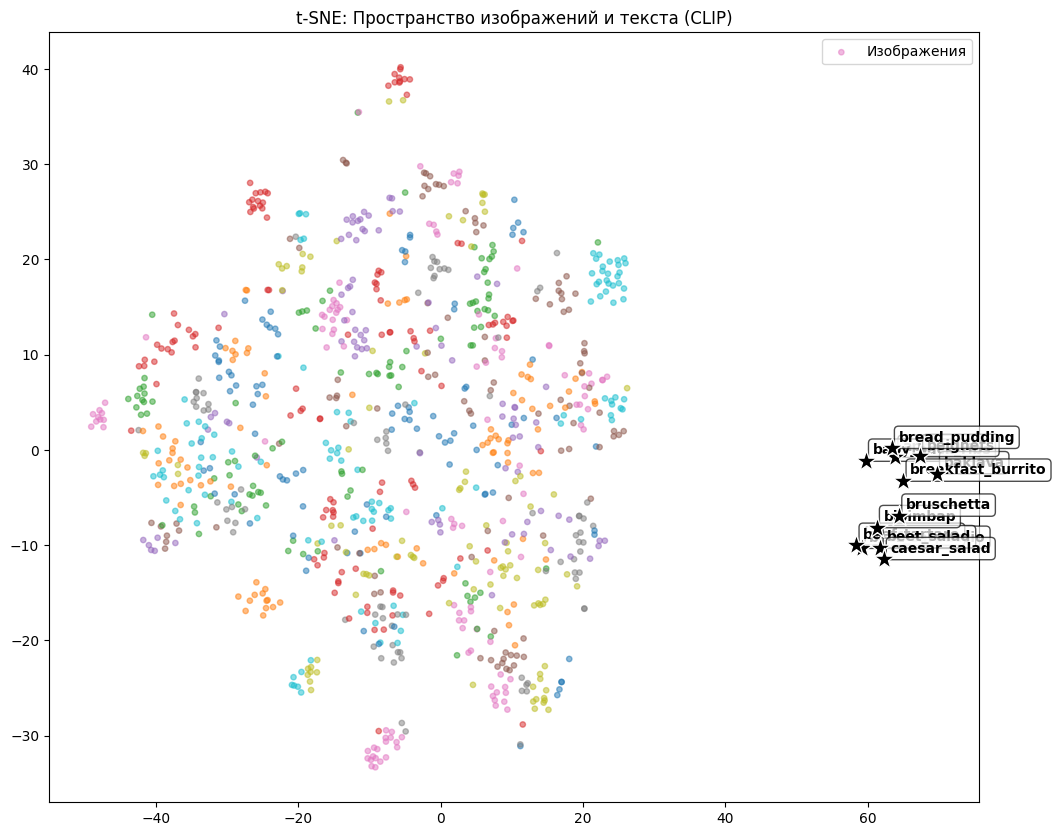

In [4]:
from sklearn.manifold import TSNE

print("--- Задание 2: Image Retrieval (Поиск по тексту) ---")

def search_by_text(query, top_k=4):
    """
    Функция для поиска наиболее подходящих изображений по текстовому запросу.
    """
    # 1. Пропускаем наш запрос через токенизатор
    inputs = processor(text=[query], return_tensors="pt", padding=True).to(device)
    
    with torch.no_grad():
        # 2. Получаем текстовый эмбеддинг для запроса
        t_feat = model.get_text_features(**inputs)
        if not isinstance(t_feat, torch.Tensor): t_feat = t_feat.pooler_output
        
        # 3. Нормализуем его (L2-нормализация)
        t_feat = t_feat / t_feat.norm(dim=-1, keepdim=True)
        
        # 4. Считаем косинусное сходство (dot product нормализованных векторов).
        # all_image_features содержит эмбеддинги всех 1500 картинок. 
        # Умножаем матрицу картинок на транспонированный вектор текста.
        # squeeze() убирает лишние размерности (превращает тензор [1500, 1] в [1500])
        similarity = (all_image_features @ t_feat.cpu().T).squeeze()
        
        # 5. Сортируем индексы картинок по убыванию сходства и берем топ-K
        top_indices = similarity.argsort(descending=True)[:top_k]
        
    return top_indices, similarity[top_indices]

def visualize_search(query, indices, scores):
    """
    Функция для отрисовки результатов поиска.
    """
    # Создаем сетку графиков: 1 строка, len(indices) колонок
    fig, axes = plt.subplots(1, len(indices), figsize=(12, 3))
    fig.suptitle(f'Запрос: "{query}"', fontsize=12, fontweight='bold', y=1.1)
    
    # Идем по найденным индексам и их скорам (оценкам уверенности)
    for i, (idx, score) in enumerate(zip(indices, scores)):
        # Достаем саму картинку и ее реальный класс из датасета
        img, true_label = test_dataset[idx.item()]
        
        axes[i].imshow(img)
        # Выводим реальное название блюда и насколько сильно CLIP уверен в совпадении
        axes[i].set_title(f"{class_names[true_label]}\nСходство: {score.item():.3f}", fontsize=10)
        axes[i].axis('off')
    plt.show()

# ==========================================
# 1. Тестируем 8 различных запросов
# ==========================================
# Здесь мы проверяем семантическое понимание CLIP. Он учился на текстах из интернета,
# поэтому понимает не только конкретные названия (пицца), но и свойства (острое, сладкое, вредное).
queries_8 = [
    "a photo of pizza",               # Прямое указание класса
    "a fresh green salad",            # Класс с описанием
    "something sweet for dessert",    # Поиск по атрибуту (сладкое/десерт)
    "a dish with meat",               # Поиск по составу (мясо)
    "a hot bowl of soup",             # Поиск по атрибуту/форме
    "a dish that looks unhealthy",    # Абстрактный запрос (вредная еда)
    "something eaten for breakfast",  # Контекстный запрос (завтрак)
    "spicy asian food"                # Сборный абстрактный запрос (острое + азиатское)
]

for q in queries_8:
    idx, scores = search_by_text(q)
    visualize_search(q, idx, scores)

# ==========================================
# 2. Подсчет качества поиска (Метрика Recall@10)
# ==========================================
print("\n--- Подсчет качества поиска (Recall@10) ---")
# Recall@10 (Полнота в топ-10) отвечает на вопрос:
# "Если мы ищем конкретный класс, окажется ли хотя бы одна картинка этого класса в первых 10 результатах?"

def recall_at_k(class_names, image_features, labels, k=10):
    recalls = {}
    for class_idx, class_name in enumerate(class_names):
        # Проверяем, есть ли вообще картинки этого класса в нашей случайной подвыборке из 1500 штук
        if class_idx not in labels: continue

        query = f"a photo of a {class_name}"
        
        # Токенизируем, извлекаем и нормализуем эмбеддинг текста (как в функции search_by_text)
        inputs = processor(text=[query], return_tensors="pt", padding=True).to(device)
        with torch.no_grad():
            t_feat = model.get_text_features(**inputs)
            if not isinstance(t_feat, torch.Tensor): t_feat = t_feat.pooler_output
            t_feat = t_feat / t_feat.norm(dim=-1, keepdim=True)
            
            # Считаем сходство со всеми картинками и берем топ-K (топ-10) индексов
            similarity = (image_features @ t_feat.cpu().T).squeeze()
            top_indices = similarity.argsort(descending=True)[:k]

        # Достаем реальные метки классов для найденных топ-10 картинок
        top_labels = labels[top_indices.numpy()]
        
        # Если искомый класс (class_idx) есть среди найденных топ-10 меток, ставим 1 (успех), иначе 0 (провал)
        recalls[class_name] = int(class_idx in top_labels)

    # Усредняем результат по всем проверенным классам
    return np.mean(list(recalls.values()))

mean_recall = recall_at_k(class_names, all_image_features, all_labels, k=10)
print(f"[РЕЗУЛЬТАТ] Mean Recall@10: {mean_recall * 100:.1f}%\n")

# ==========================================
# 3. Визуализация эмбеддингов с помощью t-SNE
# ==========================================
print("--- Визуализация эмбеддингов (t-SNE) ---")
# Наши векторы картинок и текста имеют 512 измерений. t-SNE — это алгоритм, который
# сплющивает их до 2 измерений (X и Y) так, чтобы похожие объекты остались рядом друг с другом.

# Берем максимум 1000 картинок, так как t-SNE работает очень медленно на больших объемах данных
sample_size = min(1000, len(all_image_features))
sample_idx = np.random.choice(len(all_image_features), sample_size, replace=False)

# Склеиваем векторы картинок и векторы ВСЕХ 101 текстовых описаний в один массив.
# Это нужно, чтобы t-SNE спроецировал текст и картинки в одно и то же 2D-пространство.
combined = np.vstack([all_image_features[sample_idx].numpy(), text_features.cpu().numpy()])

# Настраиваем и запускаем t-SNE. perplexity=30 — баланс между локальной и глобальной структурой.
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
combined_2d = tsne.fit_transform(combined)

plt.figure(figsize=(12, 10))

# 1. Рисуем эмбеддинги ИЗОБРАЖЕНИЙ (первые sample_size точек в массиве)
# Красим их в зависимости от класса (c=all_labels), делаем полупрозрачными (alpha=0.5)
plt.scatter(combined_2d[:sample_size, 0], combined_2d[:sample_size, 1],
            c=all_labels[sample_idx], cmap='tab10', s=15, alpha=0.5, label='Изображения')

# Чтобы не перегружать график 101 текстовой подписью, выбираем только 12 случайных классов,
# которые реально попали в выборку t-SNE
unique_labels = np.unique(all_labels[sample_idx])
labels_to_plot = unique_labels[:12]

# 2. Рисуем эмбеддинги ТЕКСТА (они лежат в конце массива combined_2d)
for class_idx in labels_to_plot:
    # Индекс текста в массиве = количество_картинок + ID_класса
    # Рисуем большие черные звезды на месте текстовых эмбеддингов
    plt.scatter(combined_2d[sample_size+class_idx, 0], combined_2d[sample_size+class_idx, 1],
                s=250, marker='*', color='black', edgecolors='white', zorder=5)
    
    # Добавляем текстовые подписи (названия классов) рядом со звездами
    plt.annotate(class_names[class_idx],
                 (combined_2d[sample_size+class_idx, 0], combined_2d[sample_size+class_idx, 1]),
                 fontsize=10, xytext=(5,5), textcoords='offset points', fontweight='bold',
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.7))

plt.title("t-SNE: Пространство изображений и текста (CLIP)\nЗвезды — это текст, точки — картинки")
plt.legend()
plt.show()